# Task 3.2 Failure Mode Analysis

**Failure Scenario Description**: The method will fail badly if the data forms complex, curved shapes (like circles inside of other circles) and we try to use a basic straight-line model.

**Why I expect it to struggle**: My first assumption in Task 1.2 stated that the model expects the data probabilities to follow a clean, linear shape. If the data is arranged in circles, finding the average features of a group will just point to the center of the circle. This means groups from the outer circle will average out to have the exact same center features as groups from the inner circle. The model will not be able to tell the difference and will just guess randomly.


Accuracy on circular data: 0.4556


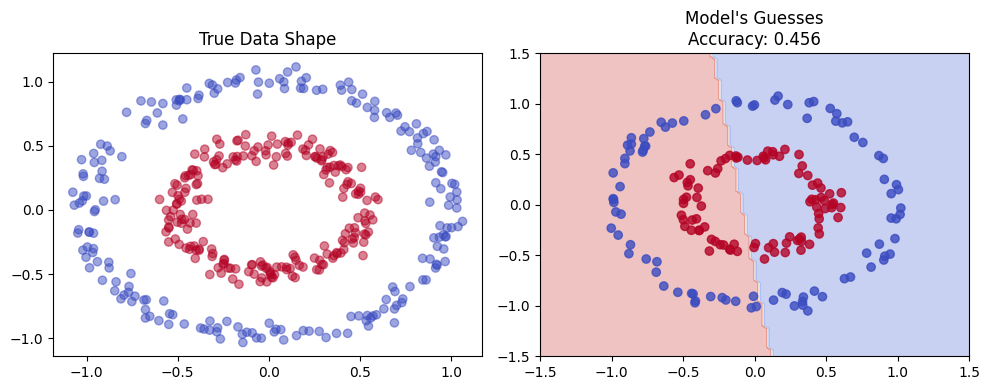

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Create a dataset that is shaped like two rings
X_circle, y_circle_raw = make_circles(n_samples=600, noise=0.05, factor=0.5, random_state=42)
y_circle = np.where(y_circle_raw == 0, -1, 1)

from sklearn.model_selection import train_test_split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_circle, y_circle, test_size=0.3, random_state=42)

k = 10
n_samples = Xc_train.shape[0]
n_groups = int(np.ceil(n_samples / k))
indices = np.arange(n_samples)
groups = [indices[i*k:min((i+1)*k, n_samples)] for i in range(n_groups)]

pc_group = []
Xc_mean = []
for g in groups:
    pc_group.append(np.sum(yc_train[g] == 1) / len(g))
    Xc_mean.append(np.mean(Xc_train[g], axis=0))

pc_group = np.array(pc_group)
Xc_mean = np.array(Xc_mean)
pc_clipped = np.clip(pc_group, 1/n_samples, 1 - 1/n_samples)
yc_targets = -np.log(1 / pc_clipped - 1)
eps_c_dynamic = 0.1 / (pc_clipped * (1 - pc_clipped))

m_c = len(groups)
d_c = Xc_train.shape[1]
wc = cp.Variable(d_c)
bc = cp.Variable()
xic = cp.Variable(m_c, nonneg=True)
xi_starc = cp.Variable(m_c, nonneg=True)

objective_c = cp.Minimize(0.5 * cp.sum_squares(wc) + 1.0 * cp.sum(xic + xi_starc))
constraints_c = [
    Xc_mean @ wc + bc >= yc_targets - eps_c_dynamic - xic,
    Xc_mean @ wc + bc <= yc_targets + eps_c_dynamic + xi_starc
]
prob_c = cp.Problem(objective_c, constraints_c)
prob_c.solve()

yc_pred = np.sign(Xc_test @ wc.value + bc.value)
acc_fail = accuracy_score(yc_test, yc_pred)

print(f"Accuracy on circular data: {acc_fail:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(Xc_train[:, 0], Xc_train[:, 1], c=yc_train, cmap='coolwarm', alpha=0.5)
ax1.set_title("True Data Shape")

# The model just guesses roughly down the middle
xx = np.linspace(-1.5, 1.5, 100)
yy = np.linspace(-1.5, 1.5, 100)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]
grid_pred = np.sign(grid @ wc.value + bc.value).reshape(XX.shape)

ax2.contourf(XX, YY, grid_pred, alpha=0.3, cmap='coolwarm')
ax2.scatter(Xc_test[:, 0], Xc_test[:, 1], c=yc_test, cmap='coolwarm', alpha=0.8)
ax2.set_title(f"Model's Guesses\nAccuracy: {acc_fail:.3f}")

plt.tight_layout()
plt.savefig('results/failure_mode_circles.png')


**Explanation of Failure**
The model failed entirely, getting an accuracy near 50%, which is as bad as flipping a coin. Because the data is shaped in circles, finding the average point for any group on the outer circle will result in a point near the very center of the circle. This makes it look mathematically identical to groups from the inner circle. The method gets completely confused because it relies on the average point being meaningful.

**Concrete Modification to Fix This**
To fix this, we need to stop using straight-line math (a linear kernel). Instead, we should use a curved math formula, like a Radial Basis Function (RBF) kernel: $K(x, x') = \exp(-\gamma ||x - x'||^2)$. Using this kernel helps the model map out circular shapes properly.
